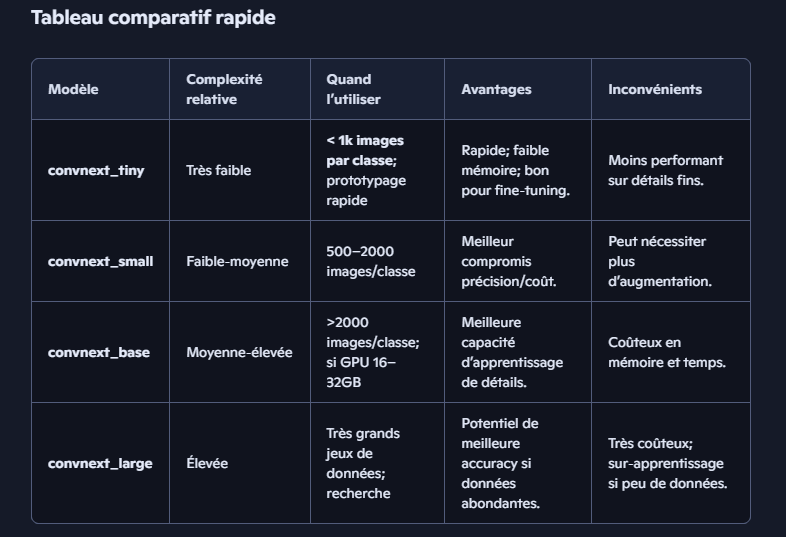

### Cellule 1 — Importations

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from torch.cuda.amp import GradScaler, autocast

# ── Chemins ──────────────────────────────────────────────────────────────────
BASE       = '/kaggle/input/datasets/stealthtechnologies/rock-classification/Rock Data'
MODEL_DIR  = '/kaggle/working'
MODEL_PATH = os.path.join(MODEL_DIR, 'convnext_best.pth')

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

NUM_CLASSES = 9
SEED        = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f'✅ Device  : {device}')
print(f'✅ BASE    : {BASE}')
print(f'✅ PyTorch : {torch.__version__}')

### Cellule 2 — Transformations & DataLoaders

In [ ]:
# ConvNeXt a été entraîné sur ImageNet avec des images 224×224
# On utilise 224 directement (pas besoin de 256→crop comme ResNet)

BATCH_SIZE = 32   # Augmenter à 64 si GPU ≥ 16 Go
IMG_SIZE   = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    # ── Augmentations géométriques ──────────────────────────────────────────
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),

    # ── Augmentations couleur ───────────────────────────────────────────────
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),

    # ── Augmentation avancée : RandAugment ─────────────────────────────────
    # Applique 2 transformations aléatoires parmi une liste prédéfinie
    # → très efficace pour la généralisation sur des datasets moyens
    transforms.RandAugment(num_ops=2, magnitude=9),

    transforms.ToTensor(),

    # Normalisation ImageNet — identique pour ConvNeXt
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),

    # ── Random Erasing (Cutout) ─────────────────────────────────────────────
    # Efface un rectangle aléatoire de l'image (15% du temps)
    # → force le modèle à ne pas se fier à une seule région
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.2)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
train_ds = datasets.ImageFolder(os.path.join(BASE, 'train'), train_transform)
valid_ds = datasets.ImageFolder(os.path.join(BASE, 'valid'), val_transform)
test_ds  = datasets.ImageFolder(os.path.join(BASE, 'test'),  val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

CLASS_NAMES = train_ds.classes
print(f'✅ Train    : {len(train_ds)} images')
print(f'✅ Valid    : {len(valid_ds)} images')
print(f'✅ Test     : {len(test_ds)} images')
print(f'✅ Classes  : {CLASS_NAMES}')

### Cellule 3 — Construction du modèle ConvNeXt

In [ ]:
# ── Choix du backbone ─────────────────────────────────────────────────────────
# convnext_tiny  : 28 M params  → rapide, bonne baseline ✅
# convnext_small : 50 M params  → bon compromis vitesse/perf 
# convnext_base  : 89 M params  → recommandé pour ce dataset 
# convnext_large : 198 M params → uniquement si GPU > 24 Go

# backbone = models.convnext_base(weights='IMAGENET1K_V1')
backbone = models.convnext_tiny(weights='IMAGENET1K_V1')

# ── Geler tous les paramètres (phase A) ───────────────────────────────────────
for param in backbone.parameters():
    param.requires_grad = False

# ── Remplacer la tête de classification ───────────────────────────────────────
# ConvNeXt termine par : backbone.classifier = Sequential(LayerNorm, Flatten, Linear)
# On récupère in_features depuis le Linear existant
in_features = backbone.classifier[2].in_features

backbone.classifier = nn.Sequential(
    nn.LayerNorm(in_features, eps=1e-6),   # Stabilise les activations
    nn.Flatten(1),
    nn.Dropout(p=0.4),                      # Régularisation
    nn.Linear(in_features, 512),
    nn.GELU(),                              # Activation native de ConvNeXt
    nn.Dropout(p=0.3),
    nn.Linear(512, NUM_CLASSES),
)

model = backbone.to(device)

# ── Résumé ────────────────────────────────────────────────────────────────────
total_params    = sum(p.numel() for p in model.parameters())
trainable_phase = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Modèle   : ConvNeXt-Base')
print(f'   Params totaux    : {total_params:,}')
print(f'   Params entraînables (Phase A) : {trainable_phase:,}')

### Cellule 4 — Fonctions utilitaires (boucles train/eval)

In [ ]:
def run_epoch_train(model, loader, criterion, optimizer, scaler):
    """Une epoch d'entraînement avec Mixed Precision (AMP)."""
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():                            # fp16 automatique
            loss = criterion(model(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    return running_loss / len(loader)


def run_epoch_eval(model, loader, criterion):
    """Une epoch d'évaluation. Retourne (loss, accuracy%)."""
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            with autocast():
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total   += labels.size(0)
    return val_loss / len(loader), 100.0 * correct / total


print('✅ Fonctions utilitaires chargées')

### Cellule 5 — Phase A : Transfer Learning (tête uniquement)

In [ ]:

from torch.amp import GradScaler

# ── Activer uniquement la tête ────────────────────────────────────────────────
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier.parameters():
    param.requires_grad = True

# Label Smoothing : réduit la sur-confiance, améliore la généralisation
# la généralisation signifie :
# la capacité du modèle à bien classifier de nouvelles images qu’il n’a jamais vues pendant l’entraînement.
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scaler     = GradScaler()         # Mixed Precision

EPOCHS_A   = 5
history    = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_acc   = 0.0

print('=' * 60)
print('PHASE A — Classifier uniquement  |  lr=1e-3')
print('=' * 60)

for epoch in range(EPOCHS_A):
    tl       = run_epoch_train(model, train_loader, criterion, optimizer, scaler)
    vl, vacc = run_epoch_eval(model, valid_loader, criterion)

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_acc'].append(vacc)

    marker = ''
    if vacc > best_acc:
        best_acc = vacc
        torch.save(model.state_dict(), MODEL_PATH)
        marker = ' ⭐'

    print(f'Epoch {epoch+1:02d}/{EPOCHS_A} — '
          f'Train: {tl:.4f} — Val: {vl:.4f} — Acc: {vacc:.2f}%{marker}')

print(f'\n✅ Phase A terminée — Meilleure acc : {best_acc:.2f}%')

Epoch 01/5 — Train: 1.6353 — Val: 1.3421 — Acc: 61.82% ⭐
Epoch 02/5 — Train: 1.3987 — Val: 1.3159 — Acc: 65.24% ⭐
Epoch 03/5 — Train: 1.3399 — Val: 1.3166 — Acc: 62.39%
Epoch 04/5 — Train: 1.2969 — Val: 1.2773 — Acc: 67.24% ⭐
Epoch 05/5 — Train: 1.2497 — Val: 1.2258 — Acc: 66.95%

✅ Phase A terminée — Meilleure acc : 67.24%

### Cellule 6 — Phase B : Fine-Tuning progressif (stages 3 → 2)

In [ ]:
# ── Architecture ConvNeXt : 4 stages + classifier ─────────────────────────────
# features[0]  : stem (patch embedding)
# features[1]  : stage 0 — concepts très bas niveau
# features[2]  : downsampling
# features[3]  : stage 1
# features[4]  : downsampling
# features[5]  : stage 2
# features[6]  : downsampling
# features[7]  : stage 3 — concepts les plus spécifiques → dégeler en premier

# Étape B1 : Dégeler stage 3
for param in model.features[7].parameters():
    param.requires_grad = True

# Taux d'apprentissage différentiels (discriminative learning rates)
# Plus on remonte dans le réseau, plus le lr est petit
optimizer_b = optim.AdamW([
    {'params': model.features[7].parameters(), 'lr': 2e-5},
    {'params': model.classifier.parameters(),  'lr': 1e-4},
], weight_decay=1e-4)

# CosineAnnealingLR : fait descendre doucement le lr sur toute la phase B
EPOCHS_B     = 30
scheduler_b  = optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=EPOCHS_B, eta_min=1e-7)
patience_ctr = 0
PATIENCE     = 8

print('=' * 60)
print('PHASE B — Stage 3 + Classifier  |  lr différentiels')
print('=' * 60)

for epoch in range(EPOCHS_B):
    # ── À la moitié de la phase B, on dégèle aussi le stage 2 ─────────────
    if epoch == EPOCHS_B // 2:
        for param in model.features[5].parameters():
            param.requires_grad = True
        # Réinitialiser l'optimizer avec le nouveau groupe
        optimizer_b = optim.AdamW([
            {'params': model.features[5].parameters(), 'lr': 5e-6},
            {'params': model.features[7].parameters(), 'lr': 1e-5},
            {'params': model.classifier.parameters(),  'lr': 5e-5},
        ], weight_decay=1e-4)
        remaining = EPOCHS_B - epoch
        scheduler_b = optim.lr_scheduler.CosineAnnealingLR(
            optimizer_b, T_max=remaining, eta_min=1e-7
        )
        print(f'  → Stage 2 dégelé à l\'epoch {epoch+1}')

    tl       = run_epoch_train(model, train_loader, criterion, optimizer_b, scaler)
    vl, vacc = run_epoch_eval(model, valid_loader, criterion)
    scheduler_b.step()

    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_acc'].append(vacc)

    marker = ''
    if vacc > best_acc:
        best_acc     = vacc
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH)
        marker = ' ⭐'
    else:
        patience_ctr += 1

    lr_now = optimizer_b.param_groups[-1]['lr']
    print(f'Epoch {epoch+1:02d}/{EPOCHS_B} — '
          f'Train: {tl:.4f} — Val: {vl:.4f} — Acc: {vacc:.2f}% '
          f'lr={lr_now:.2e}{marker}')

    if patience_ctr >= PATIENCE:
        print(f'⏹️  Early stopping à l\'epoch {epoch+1}')
        break

print(f'\n✅ Meilleure accuracy finale : {best_acc:.2f}%')
print(f'✅ Modèle sauvegardé : {MODEL_PATH}')

Epoch 01/30 — Train: 1.1759 — Val: 1.2140 — Acc: 67.52% lr=9.97e-05 ⭐
Epoch 02/30 — Train: 1.1519 — Val: 1.2013 — Acc: 67.52% lr=9.89e-05
Epoch 03/30 — Train: 1.1074 — Val: 1.2051 — Acc: 68.95% lr=9.76e-05 ⭐
Epoch 04/30 — Train: 1.0910 — Val: 1.1982 — Acc: 69.52% lr=9.57e-05 ⭐
Epoch 05/30 — Train: 1.0675 — Val: 1.1885 — Acc: 70.09% lr=9.33e-05 ⭐
Epoch 06/30 — Train: 1.0453 — Val: 1.1945 — Acc: 69.80% lr=9.05e-05
Epoch 07/30 — Train: 1.0377 — Val: 1.1824 — Acc: 70.94% lr=8.72e-05 ⭐
Epoch 08/30 — Train: 1.0203 — Val: 1.1900 — Acc: 69.23% lr=8.35e-05
Epoch 09/30 — Train: 1.0074 — Val: 1.1773 — Acc: 70.66% lr=7.94e-05
Epoch 10/30 — Train: 1.0057 — Val: 1.1824 — Acc: 69.80% lr=7.50e-05
Epoch 11/30 — Train: 0.9792 — Val: 1.1781 — Acc: 70.94% lr=7.04e-05
Epoch 12/30 — Train: 0.9757 — Val: 1.1825 — Acc: 70.66% lr=6.55e-05
Epoch 13/30 — Train: 0.9642 — Val: 1.1812 — Acc: 71.23% lr=6.04e-05 ⭐
Epoch 14/30 — Train: 0.9583 — Val: 1.1759 — Acc: 71.79% lr=5.53e-05 ⭐
Epoch 15/30 — Train: 0.9505 — Val: 1.1823 — Acc: 71.79% lr=5.01e-05
  → Stage 2 dégelé à l'epoch 16
Epoch 16/30 — Train: 0.9399 — Val: 1.1835 — Acc: 72.08% lr=4.95e-05 ⭐
Epoch 17/30 — Train: 0.9207 — Val: 1.1805 — Acc: 72.65% lr=4.78e-05 ⭐
Epoch 18/30 — Train: 0.8991 — Val: 1.1724 — Acc: 71.51% lr=4.52e-05
Epoch 19/30 — Train: 0.8989 — Val: 1.1694 — Acc: 72.36% lr=4.17e-05
Epoch 20/30 — Train: 0.8830 — Val: 1.1754 — Acc: 71.51% lr=3.75e-05
Epoch 21/30 — Train: 0.8595 — Val: 1.1706 — Acc: 71.79% lr=3.28e-05
Epoch 22/30 — Train: 0.8630 — Val: 1.1630 — Acc: 72.08% lr=2.77e-05
Epoch 23/30 — Train: 0.8605 — Val: 1.1661 — Acc: 72.65% lr=2.24e-05
Epoch 24/30 — Train: 0.8662 — Val: 1.1663 — Acc: 71.79% lr=1.73e-05
Epoch 25/30 — Train: 0.8584 — Val: 1.1653 — Acc: 72.93% lr=1.26e-05 ⭐
Epoch 26/30 — Train: 0.8351 — Val: 1.1672 — Acc: 72.36% lr=8.36e-06
Epoch 27/30 — Train: 0.8460 — Val: 1.1645 — Acc: 72.65% lr=4.87e-06
Epoch 28/30 — Train: 0.8445 — Val: 1.1642 — Acc: 72.65% lr=2.26e-06
Epoch 29/30 — Train: 0.8397 — Val: 1.1633 — Acc: 72.65% lr=6.45e-07
Epoch 30/30 — Train: 0.8349 — Val: 1.1634 — Acc: 72.65% lr=1.00e-07

✅ Meilleure accuracy finale : 72.93%
✅ Modèle sauvegardé : /kaggle/working/convnext_best.pth

### Cellule 7 — Évaluation sur le dataset de Test

In [ ]:
# Charger les meilleurs poids avant l'overfitting
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

test_loss, test_acc = run_epoch_eval(model, test_loader, criterion)

print(f'🎯 Accuracy sur le Test set : {test_acc:.2f}%')
print(f'📉 Loss sur le Test set    : {test_loss:.4f}')

🎯 Accuracy sur le Test set : 75.29%
📉 Loss sur le Test set    : 1.0924

### Cellule 8 — Courbes d'entraînement

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

train_losses = history['train_loss']
val_losses   = history['val_loss']
val_accs     = history['val_acc']
epochs_range = range(1, len(train_losses) + 1)
sep          = EPOCHS_A  # Séparateur phase A / phase B

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ConvNeXt-Base — Entraînement GeoScanner', fontsize=15, y=1.02)

# ── Graphique 1 : Loss ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs_range, train_losses, 'b-',  label='Train Loss')
ax.plot(epochs_range, val_losses,   'r-',  label='Val Loss')
ax.axvline(sep + 0.5, color='gray', linestyle='--', linewidth=1.2, label='A → B')
ax.set_title('Évolution de la Loss')
ax.set_xlabel('Époques (A + B)')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# ── Graphique 2 : Accuracy ────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs_range, val_accs, 'g-', linewidth=2, label='Val Accuracy')
ax.axvline(sep + 0.5, color='gray', linestyle='--', linewidth=1.2, label='A → B')
best_epoch = val_accs.index(max(val_accs)) + 1
ax.axvline(best_epoch, color='gold', linestyle=':', linewidth=1.5,
           label=f'Best ({max(val_accs):.2f}%)')
ax.set_title('Évolution de l\'Accuracy (Validation)')
ax.set_xlabel('Époques (A + B)')
ax.set_ylabel('Accuracy (%)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Courbes sauvegardées dans /kaggle/working/training_curves.png')

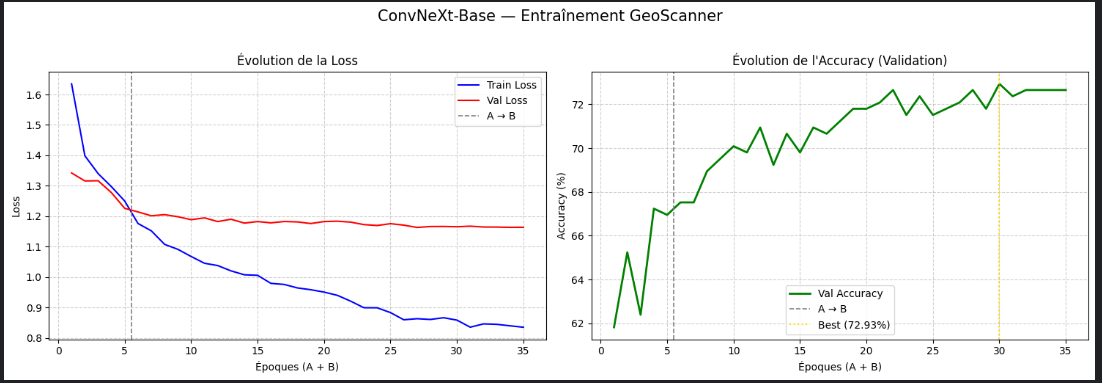

### Cellule 9 — Matrice de Confusion

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        with autocast():
            outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

# ── Matrice normalisée (pourcentages) ──────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.1f'],
    ['Matrice de Confusion (comptes)', 'Matrice de Confusion (% par classe)'],
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, cbar_kws={'shrink': 0.75}, ax=ax)
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Prédictions', fontsize=11)
    ax.set_ylabel('Réalité', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📋 Rapport de classification détaillé :')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

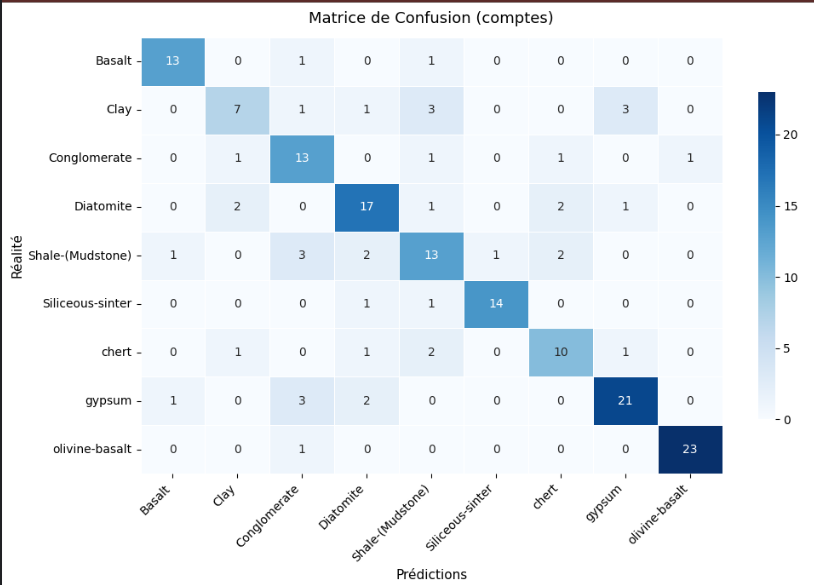

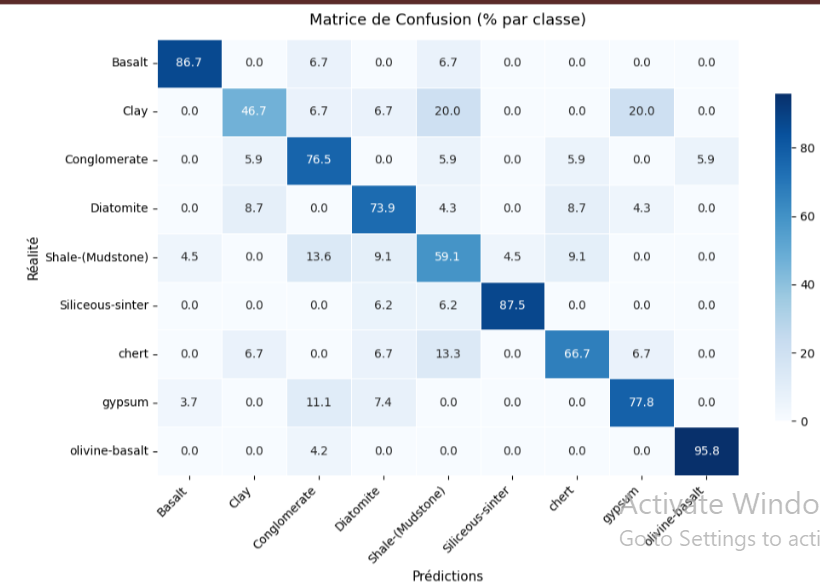


📋 Rapport de classification détaillé :
                  precision    recall  f1-score   support

          Basalt       0.87      0.87      0.87        15
            Clay       0.64      0.47      0.54        15
    Conglomerate       0.59      0.76      0.67        17
       Diatomite       0.71      0.74      0.72        23
Shale-(Mudstone)       0.59      0.59      0.59        22
Siliceous-sinter       0.93      0.88      0.90        16
           chert       0.67      0.67      0.67        15
          gypsum       0.81      0.78      0.79        27
  olivine-basalt       0.96      0.96      0.96        24

        accuracy                           0.75       174
       macro avg       0.75      0.75      0.75       174
    weighted avg       0.76      0.75      0.75       174


In [ ]:
import torch.nn.functional as F

model.eval()
errors = []   # (image_tensor, true_label, pred_label, confidence)

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        with autocast():
            outputs = model(images)
        probs         = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, 1)
        mask = preds.ne(labels)
        for img, t, p, c in zip(images[mask], labels[mask], preds[mask], confidences[mask]):
            errors.append((img.cpu(), t.item(), p.item(), c.item()))

print(f'❌ Total erreurs : {len(errors)} / {len(test_ds)}')

# ── Afficher les 12 erreurs les plus confiantes ────────────────────────────────
errors.sort(key=lambda x: -x[3])
show = min(12, len(errors))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('❌ Erreurs les plus confiantes', fontsize=14)

for i, ax in enumerate(axes.flat):
    if i >= show:
        ax.axis('off')
        continue
    img, t, p, c = errors[i]
    img_denorm = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img_denorm)
    ax.set_title(
        f'Réel : {CLASS_NAMES[t]}\nPrédit : {CLASS_NAMES[p]} ({c*100:.1f}%)',
        fontsize=8, color='red'
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/top_errors.png', dpi=150, bbox_inches='tight')
plt.show()

### Cellule 11 — Telecharger le fichier des poids

In [ ]:
from IPython.display import FileLink
import os

# Ton chemin tel que tu l'as défini
MODEL_PATH = os.path.join(MODEL_DIR, 'convnext_best.pth')

# Vérification de sécurité avant le téléchargement
if os.path.exists(MODEL_PATH):
    print("✅ Fichier trouvé ! Clique sur le lien ci-dessous pour le télécharger :")
    display(FileLink(MODEL_PATH))
else:
    print("❌ Erreur : Le fichier est introuvable. Vérifie le chemin MODEL_DIR.")